In [1]:
# jax ecosystem
import jax

jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from amigo.fitting import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots  # to use matplotlib style "science"

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA H200


In [2]:
from socket import gethostname

print(gethostname())
if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    path = "/Volumes/morgana1/snert/max/"
    # path = "/Volumes/research-data/PRJ-PAT/max/"

elif gethostname().startswith("max-"):
    path = "/home/dgxuser/max/"
else:
    path = "/fred/oz440/max/"

source_name = "PDS70"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
# output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

max-imagev2-0-39



# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        continue

    elif bool(file[0].header["IS_PSF"]):
        # file[0].header["TARGPROP"] = "HD228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

files = cal_files

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}, PWCPOS {h["PWCPOS"]}'
    )
    t0 = t


------------------------------

TD-CAL-HD-123991 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785, Groups: 29, Ints: 418, PWCPOS 205.0233309999992
TD-CAL-HD-123991 F430M, Dither 1/1, Roll 302.2deg, 12.7min, 2023-02-24 19:36:30.612, Groups: 20, Ints: 507, PWCPOS 205.0233309999996
TD-CAL-HD-123991 F380M, Dither 1/1, Roll 302.2deg, 7.7min, 2023-02-24 19:49:00.589, Groups: 10, Ints: 612, PWCPOS 205.02333100000027


/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## Building the model

In [5]:
from amigo.model_fits import PointFit, SplineVisFit
from dorito.models import ResolvedAmigoModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# cal_exps = [PointFit(file) for file in cal_files[0:1]]
cal_exps = [PointFit(file) for file in cal_files]

exposures = cal_exps

model = amigo.core_models.AmigoModel(
    exposures=exposures,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    vis_model=amigo.vis_models.LogVisModel(
        load_dict(cache + "vis_basis.npy"), n_basis=420
    ),
    state=load_dict(cache + "calibration.npy"),
)


File 01242_004_02_03_1
Star TD-CAL-HD-123991
Filter F480M
nints 418
ngroups 29



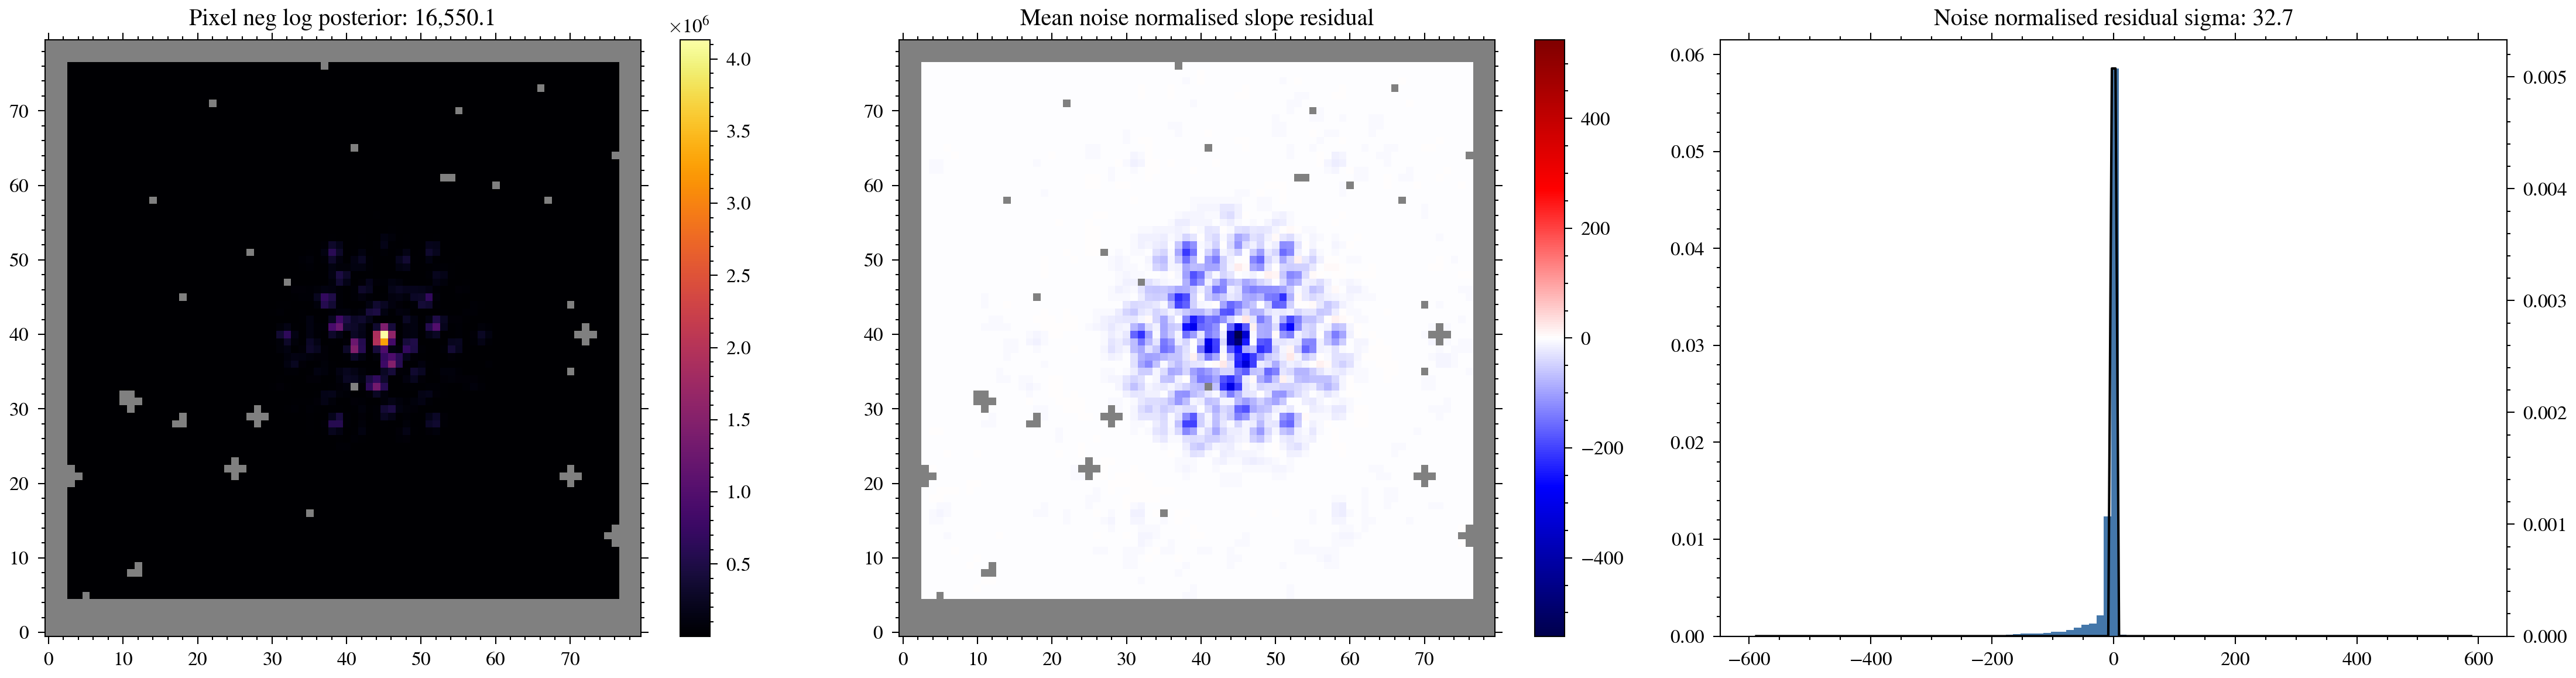

File 01242_004_03_03_1
Star TD-CAL-HD-123991
Filter F430M
nints 507
ngroups 20



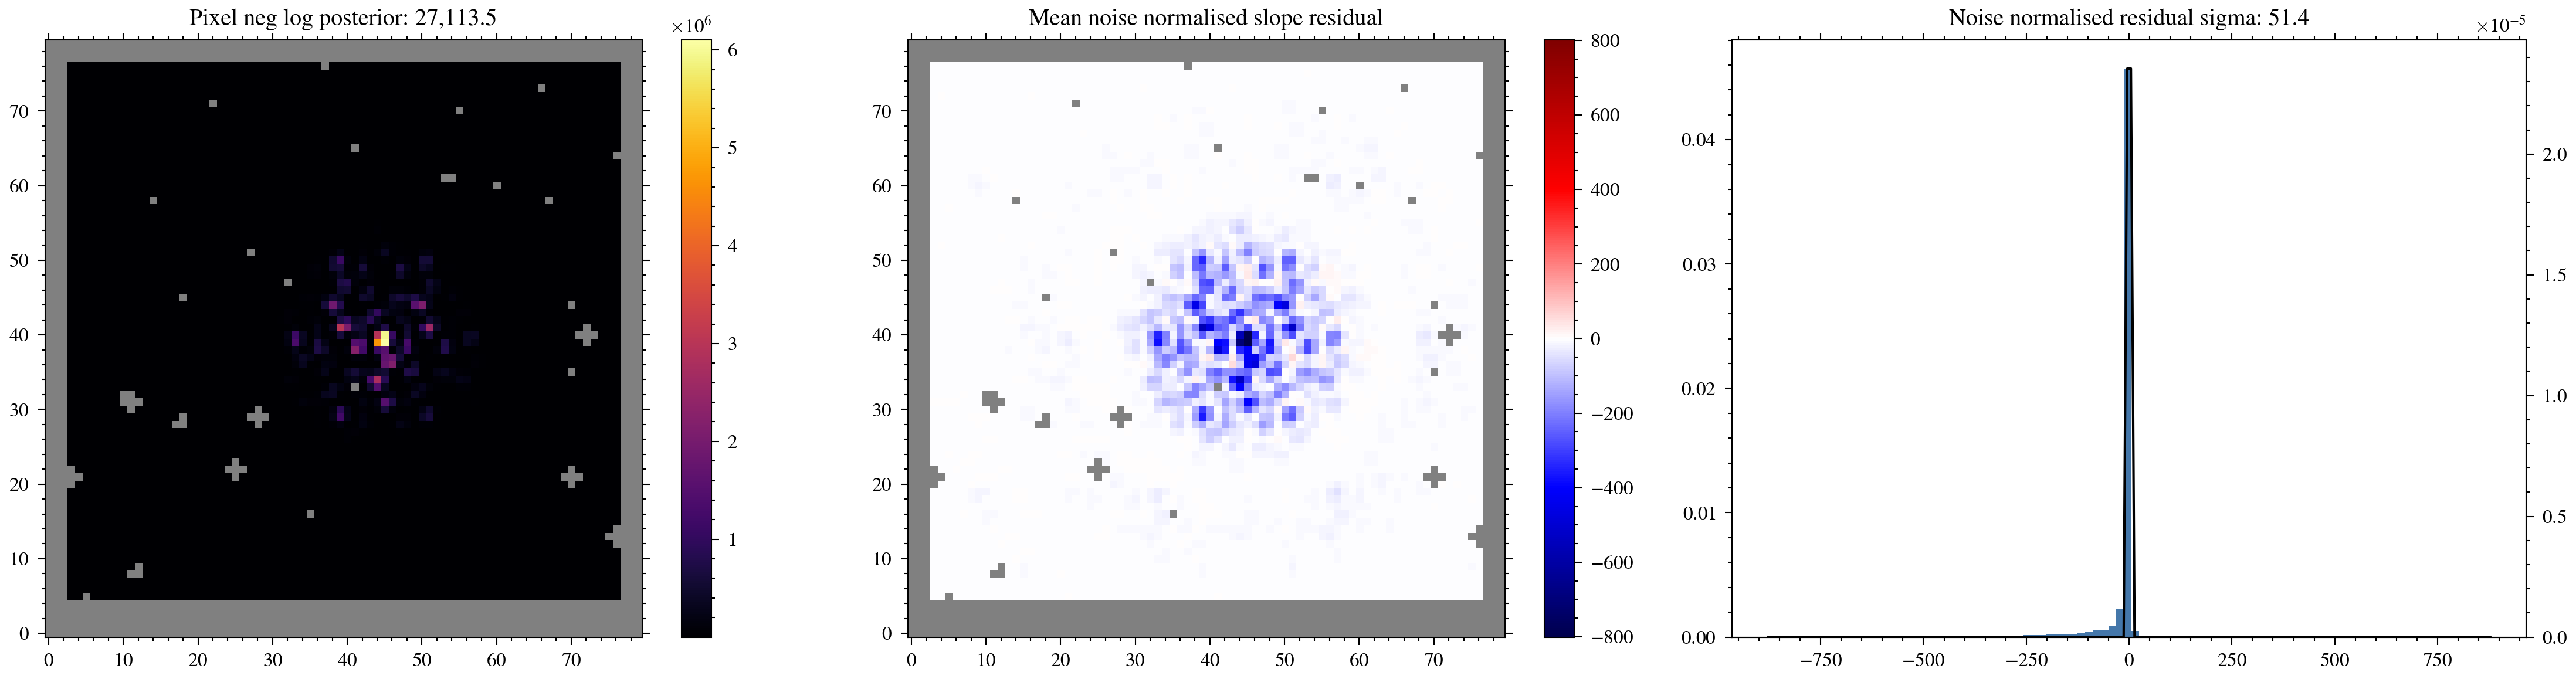

File 01242_004_04_03_1
Star TD-CAL-HD-123991
Filter F380M
nints 612
ngroups 10



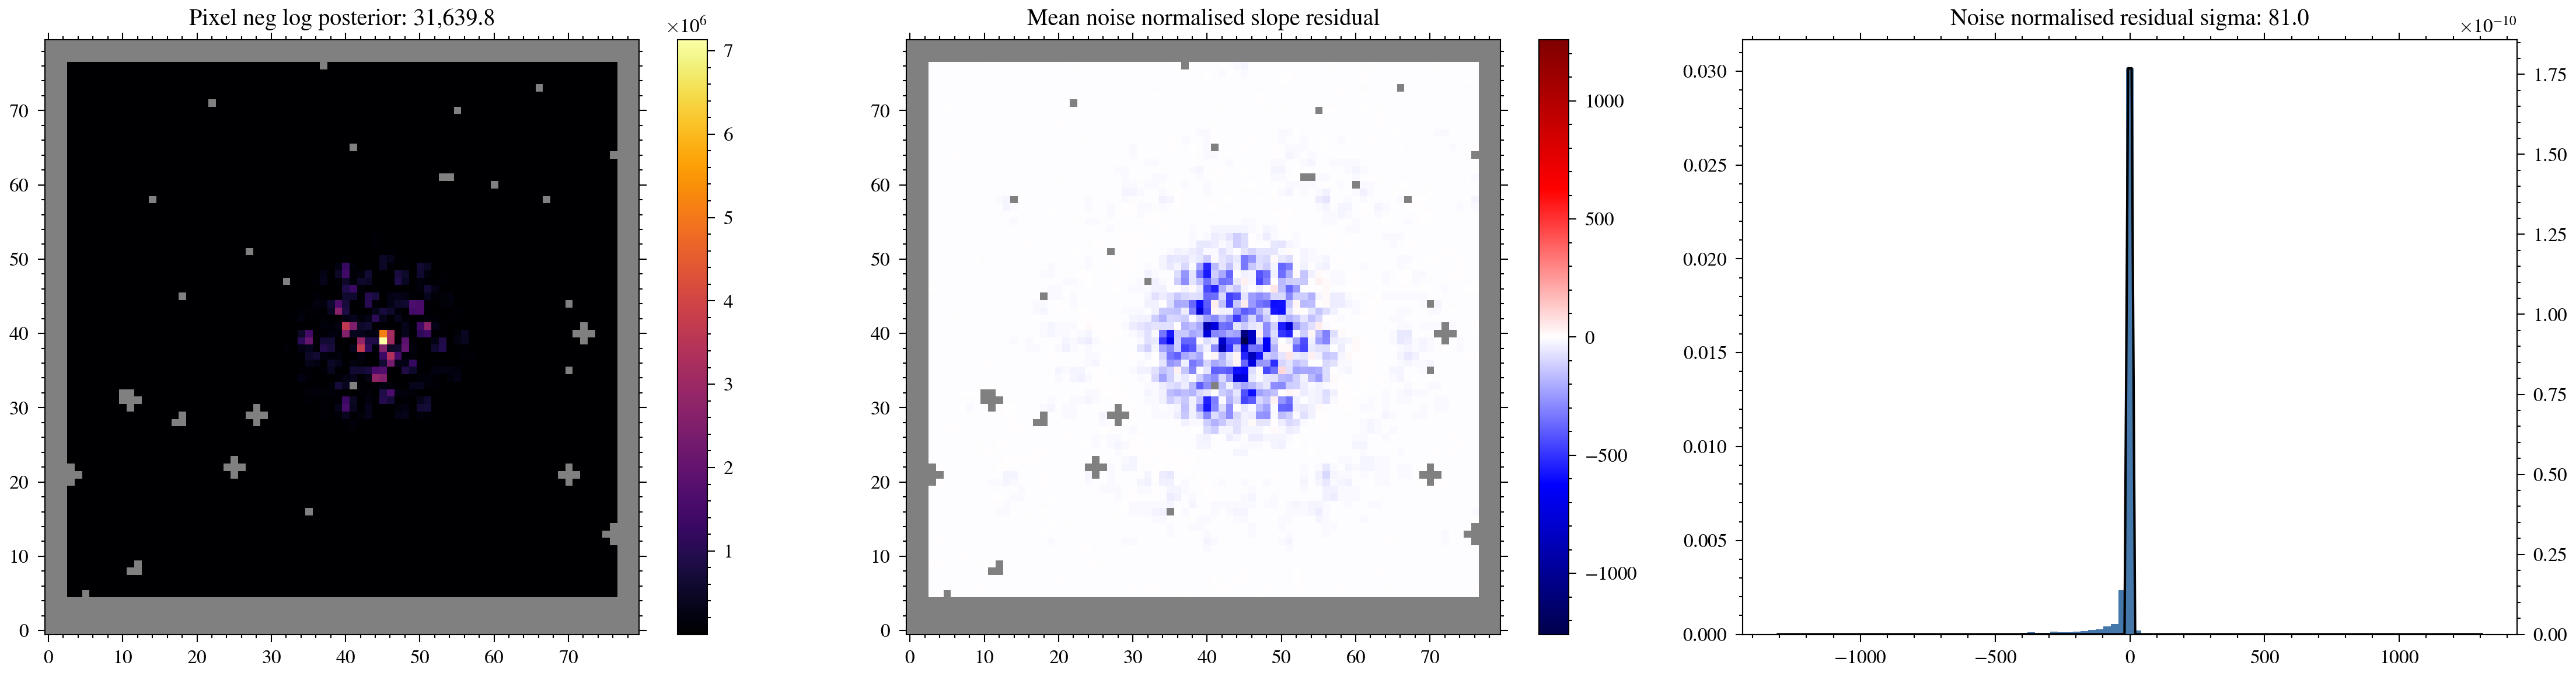

In [6]:
for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False)

## Optimisation Stage 1: Gradient Descent

In [7]:
def norm_fn(model_params, args):
    params = model_params.params
    
    if "spectra" in params.keys():
        spectra = jax.tree.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args

In [8]:
n_epoch = 100

pos_keys = []
spc_keys = []
flx_keys = []
for exp in exposures:
    if not exp.calibrator:
        spc_keys.append(exp.map_param("spectra"))
        pos_keys.append(exp.map_param("positions"))
        flx_keys.append(exp.map_param("fluxes"))

config = {
    "positions": sgd(1e-2, 0),
    "fluxes": sgd(5e-2, 0),
    "aberrations": sgd(1e-2, 4),
    "spectra": sgd(1e-1, 10),
}

def grad_fn(model, grads, args):
    return grads, args


trainer = amigo.fitting.Trainer(
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

trainer = trainer.populate_fishers(
    model,
    exposures,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=list(config.keys()),
)

print("Number of exposures: ", len(exposures))

# Train the model
# with jax.disable_jit():
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exposures,
)

Number of exposures:  3


  0%|          | 0/100 [00:00<?, ?it/s]

Compiling Loss function...
{'01242_F380M': JitTracer(float64[7,10]), '01242_F430M': JitTracer(float64[7,10]), '01242_F480M': JitTracer(float64[7,10])}
Compiling update function...

Initial_loss Loss: 50,194.26
Estimated run time: 0:01:06
Full Time: 0:01:46
Final Loss: 663.74


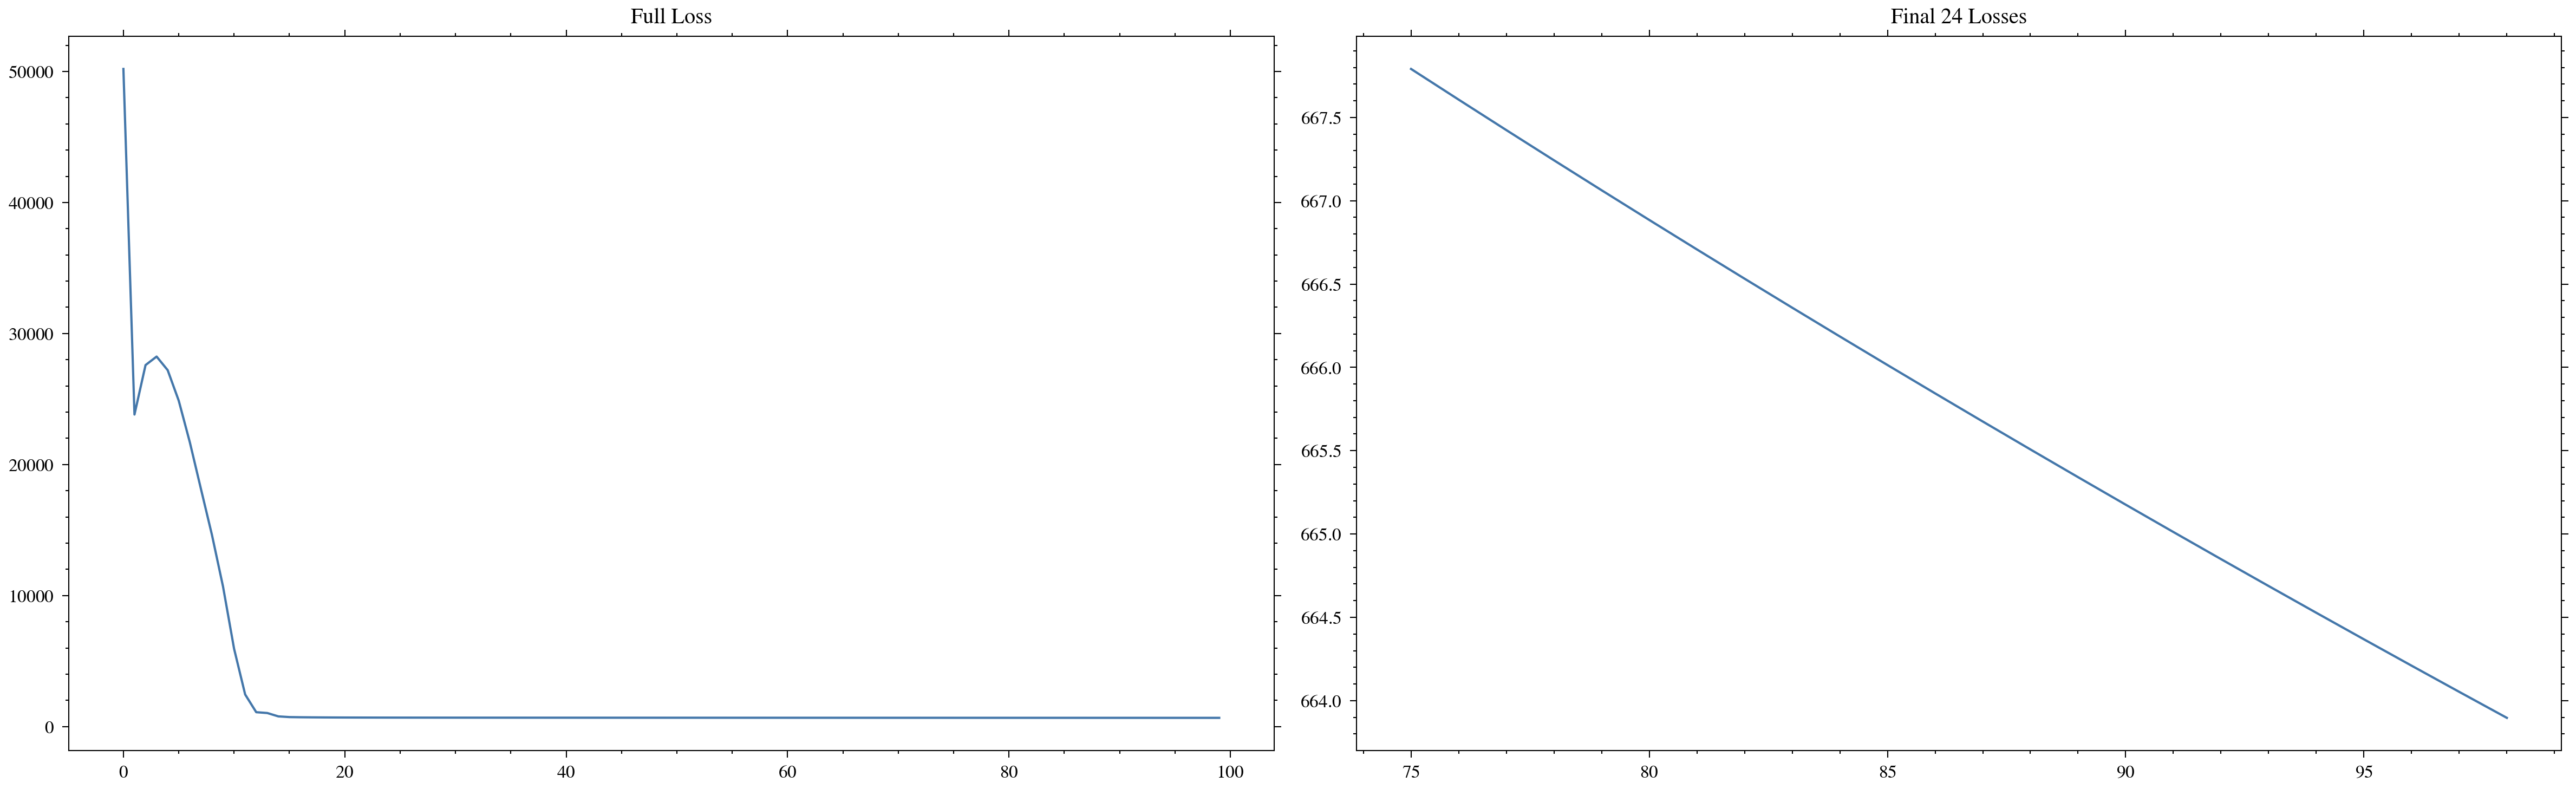

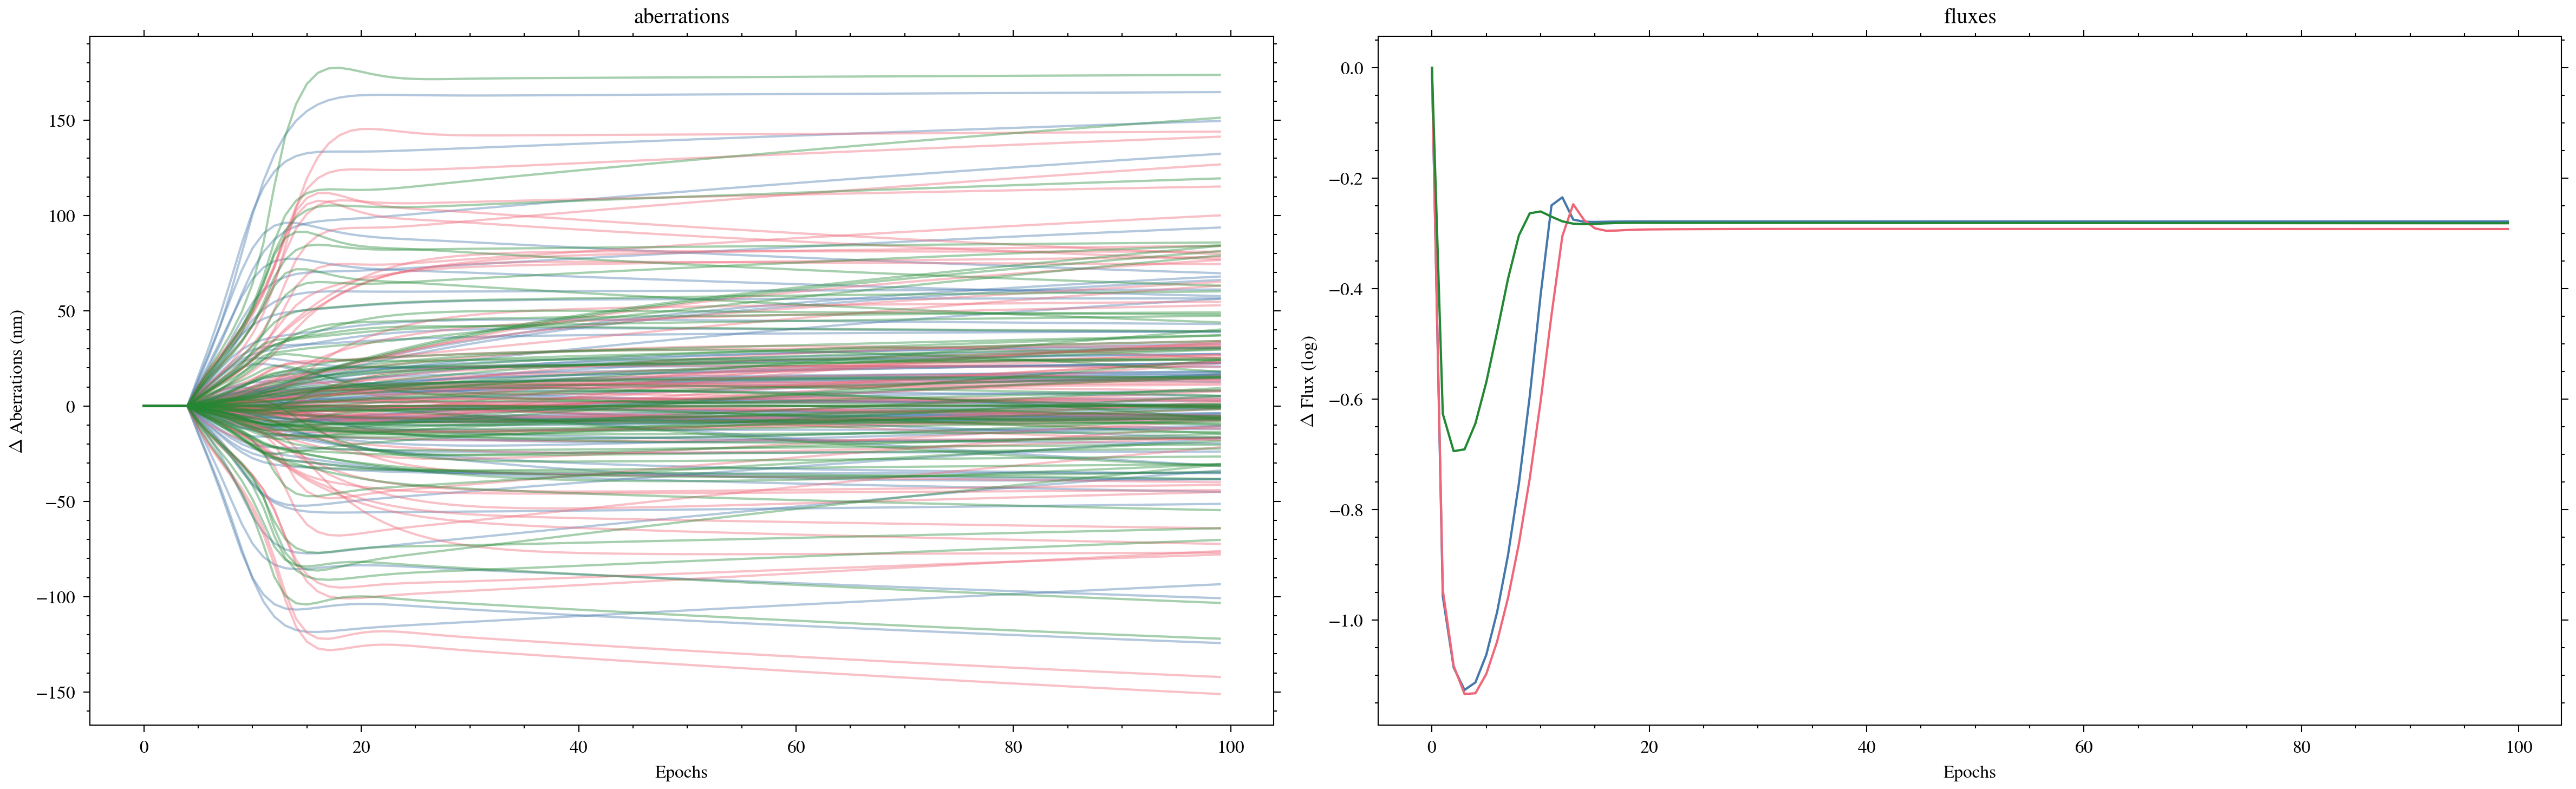

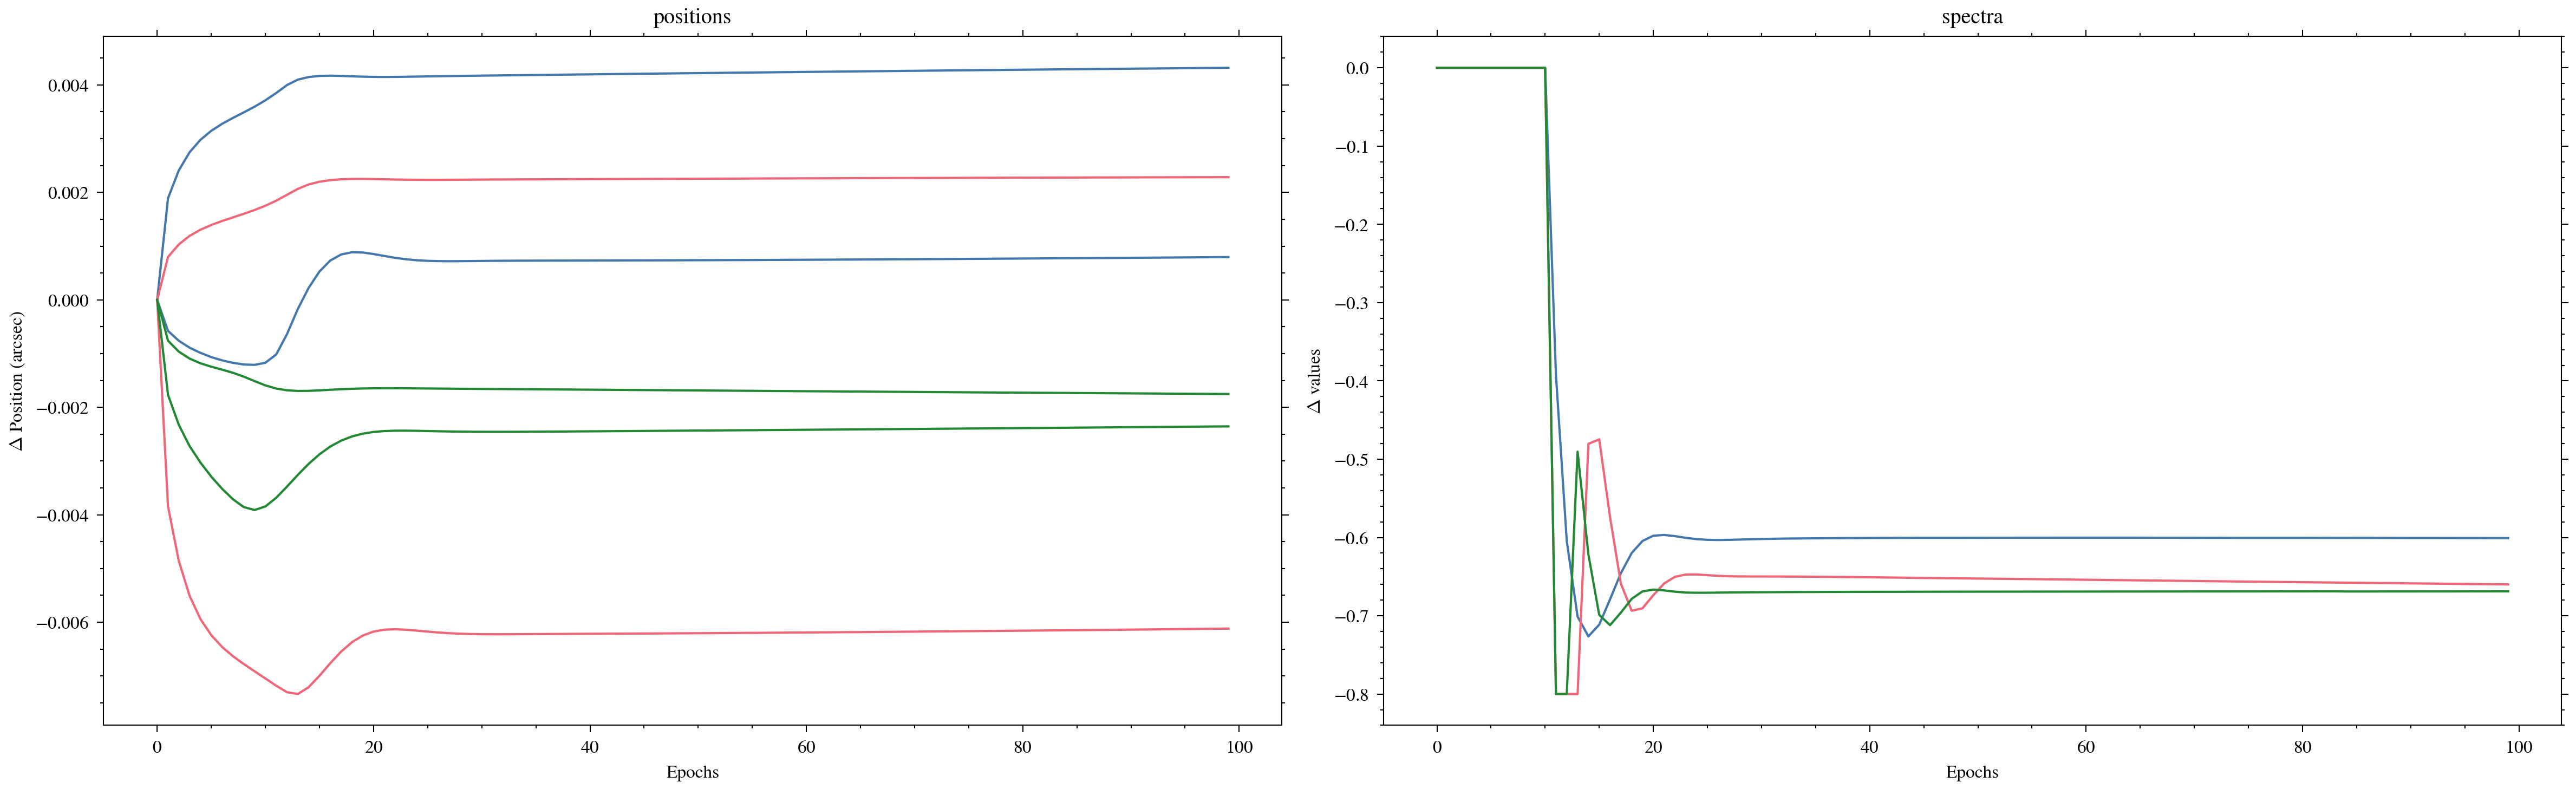

File 01242_004_02_03_1
Star TD-CAL-HD-123991
Filter F480M
nints 418
ngroups 29



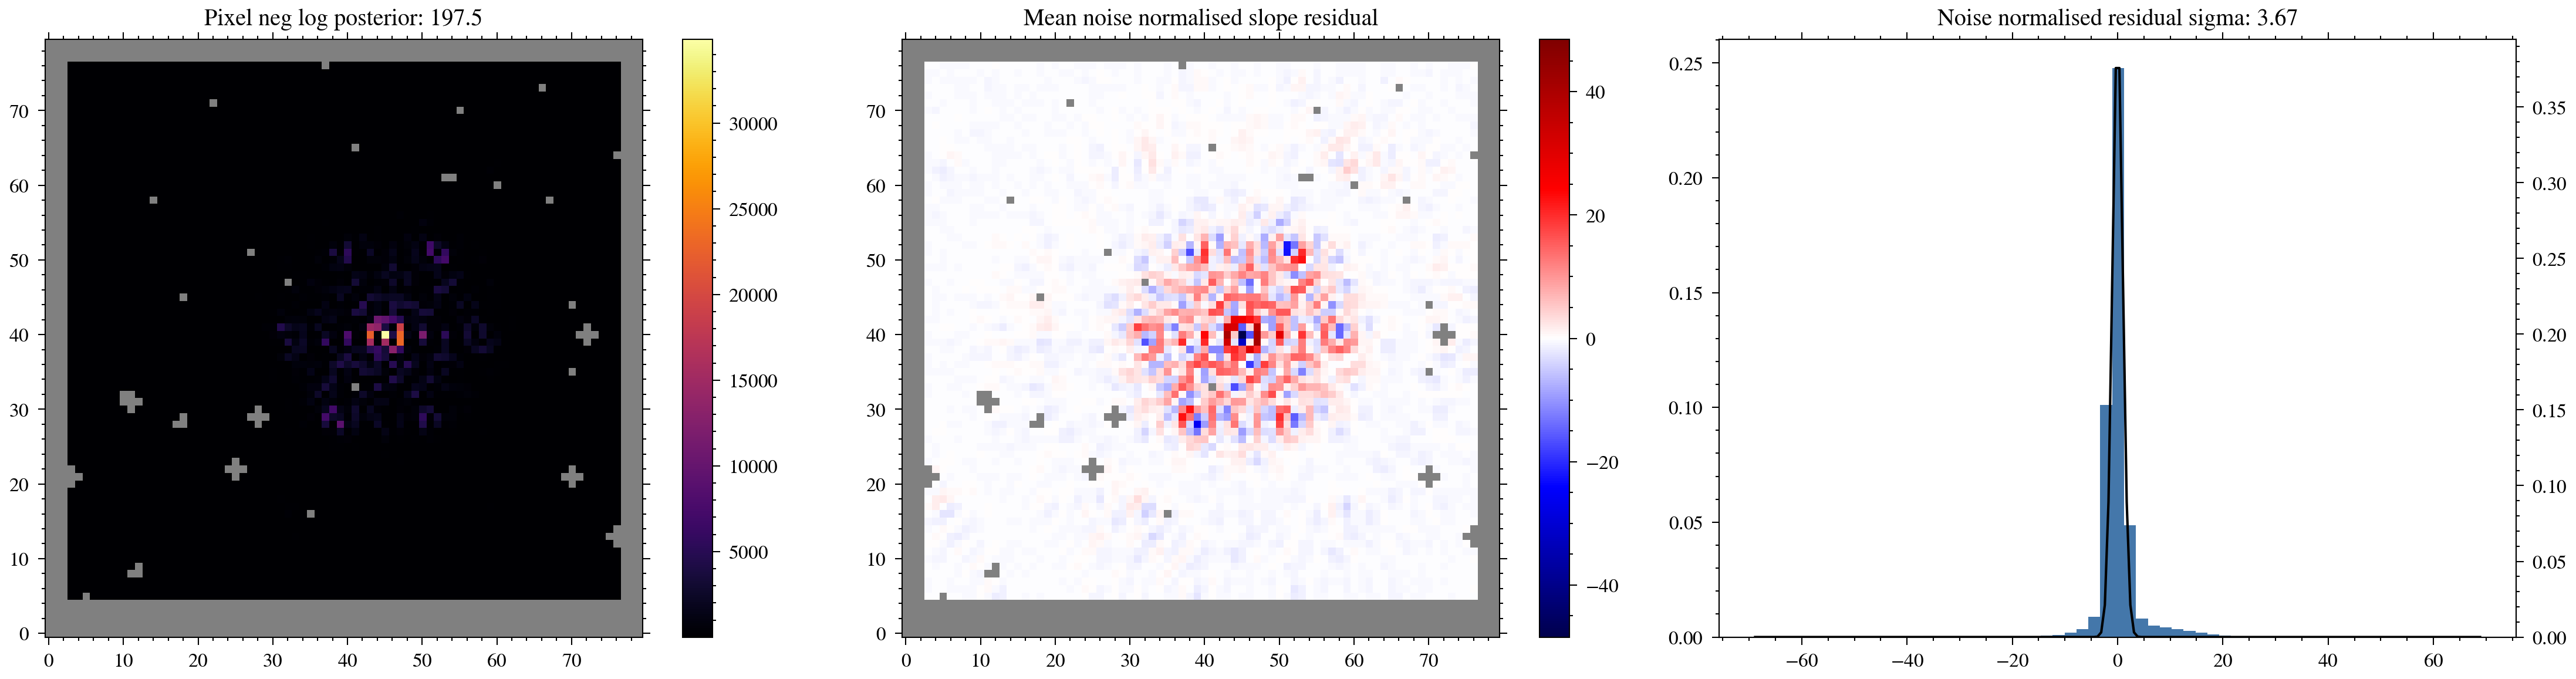

File 01242_004_03_03_1
Star TD-CAL-HD-123991
Filter F430M
nints 507
ngroups 20



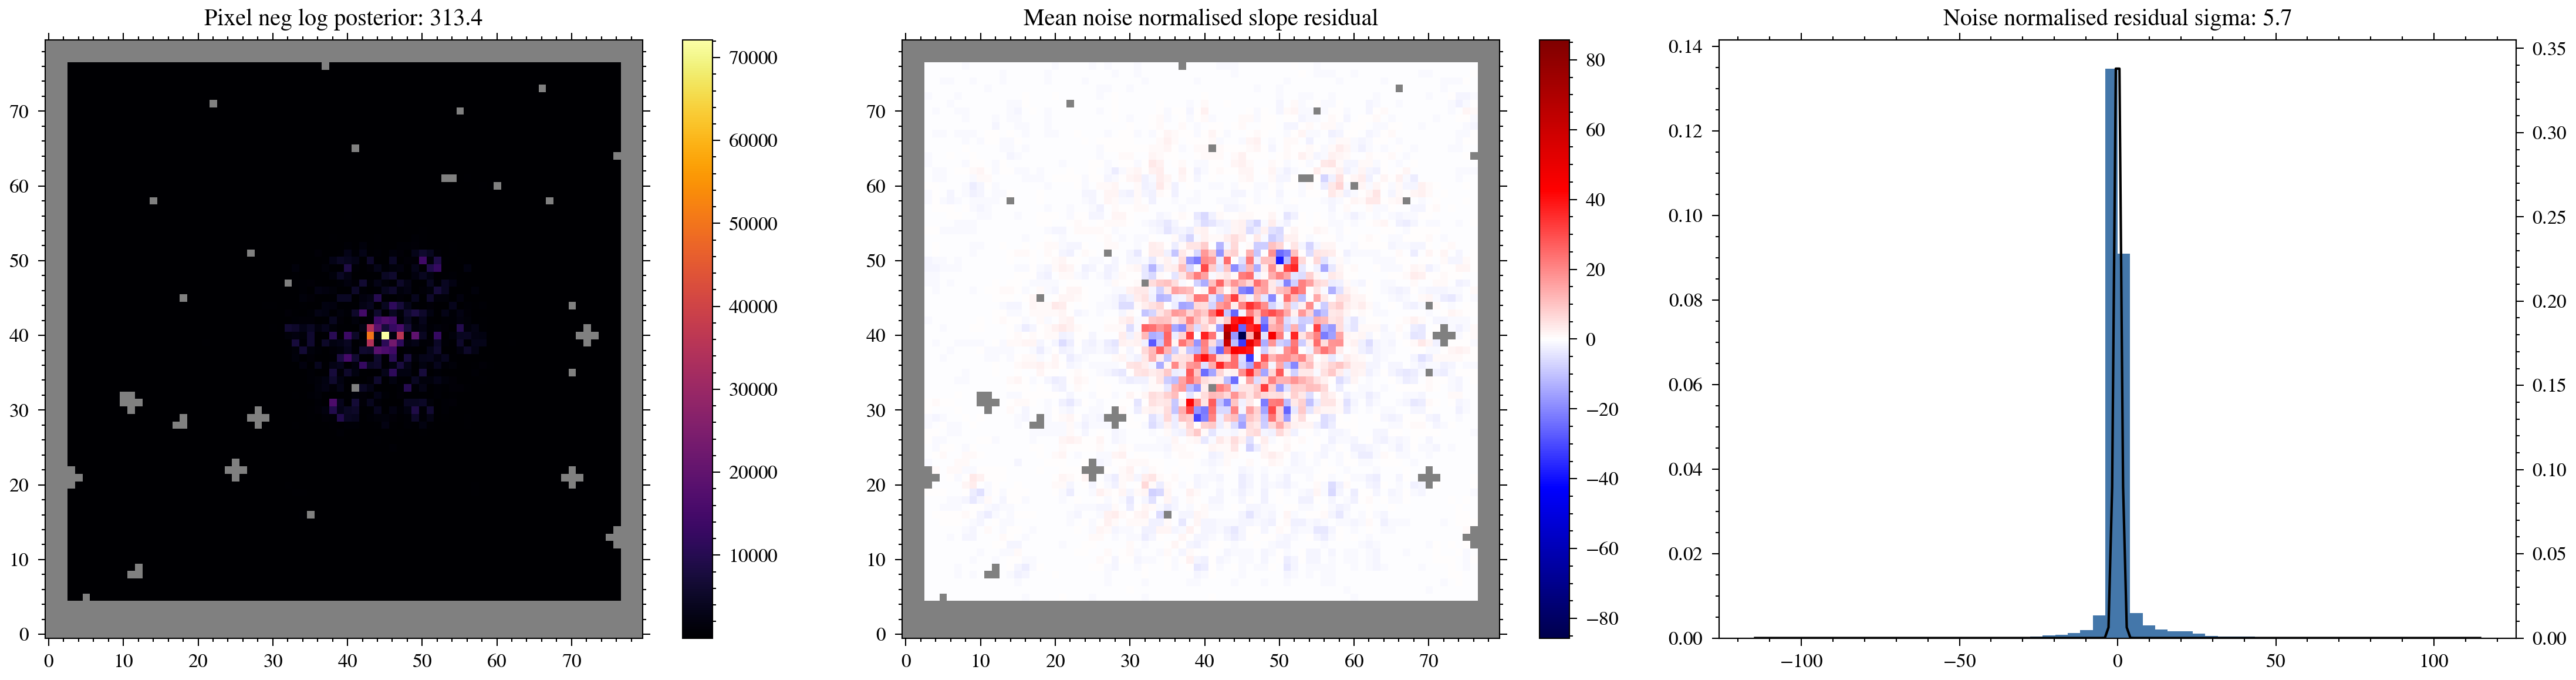

File 01242_004_04_03_1
Star TD-CAL-HD-123991
Filter F380M
nints 612
ngroups 10



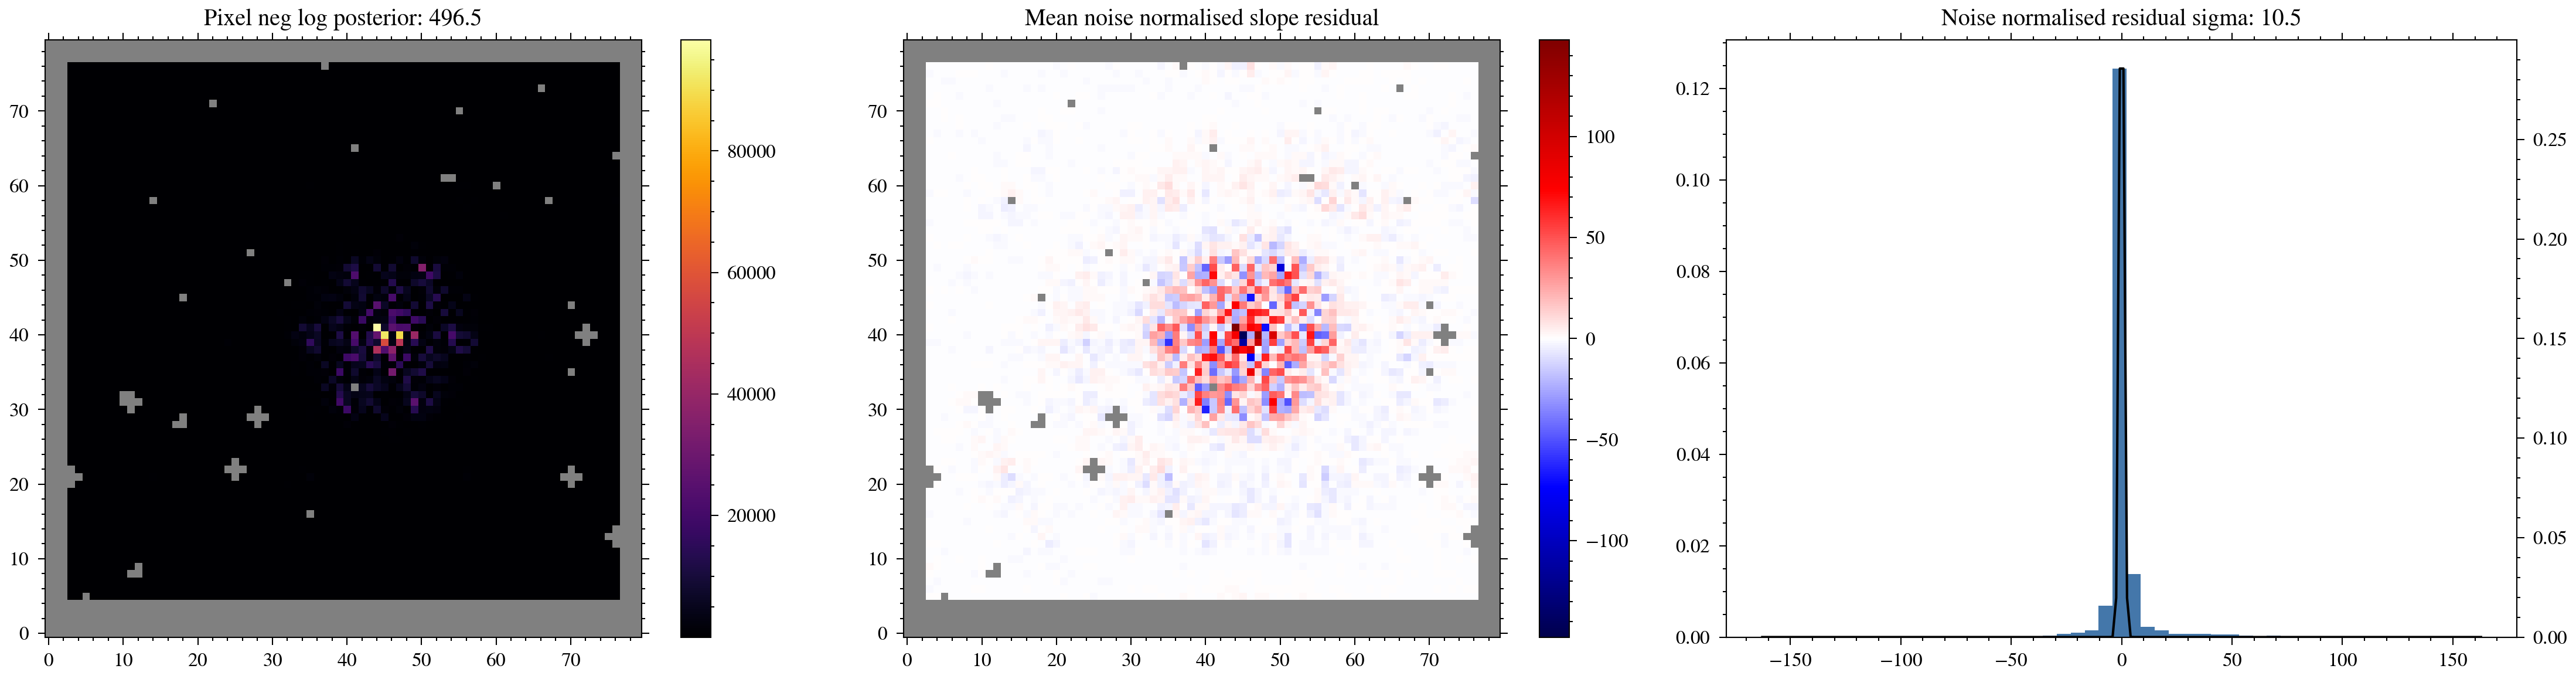

In [9]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        result.model,
        exp,
        # up_the_ramp=True,
        # up_the_ramp_norm=True,
    )

In [10]:
# for exp in exposures:

#     exp.print_summary()
    
#     badpix = exp.badpix
#     data = exp.slopes.at[:, badpix].set(np.nan)
#     slopes = exp(result.model).at[:, badpix].set(np.nan)
#     residuals = data - slopes
#     norm_res_slopes = residuals / (exp.variance**0.5)
    
#     residuals_max = np.nanmax(residuals)
#     norm_res_max = np.nanmax(norm_res_slopes)
    
#     for i in range(len(slopes)):
#         fig, ax = plt.subplots(1, 4, figsize=(14, 2.4))
#         im = ax[0].imshow(data[i], cmap=inferno, norm=mpl.colors.PowerNorm(0.5))
#         ax[0].set(
#             title="Slope (Data)",
#         )
#         fig.colorbar(im, ax=ax[0])
    
#         #
#         im = ax[1].imshow(slopes[i], cmap=inferno, norm=mpl.colors.PowerNorm(0.5))
#         ax[1].set(
#             title="Slope (Model)",
#         )
#         fig.colorbar(im, ax=ax[1])
    
#         #
#         im = ax[2].imshow(residuals[i], cmap=seismic, norm=mpl.colors.CenteredNorm(0, residuals_max))
#         ax[2].set(
#             title="Residual",
#         )
#         fig.colorbar(im, ax=ax[2])
    
#         #
#         im = ax[3].imshow(norm_res_slopes[i], cmap=seismic, norm=mpl.colors.CenteredNorm(0, norm_res_max))
#         ax[3].set(
#             title="Noise Normalised Residual",
#         )
#         fig.colorbar(im, ax=ax[3])
        
#         for j in range(len(ax)):
#             ax[j].axis("off")
#         plt.show()

In [11]:
# pixel_index = (40, 40)

# onepix_slope = slopes[:, pixel_index[0], pixel_index[1]]
# onepix_data = data[:, pixel_index[0], pixel_index[1]]
# onepix_res = residuals[:, pixel_index[0], pixel_index[1]]


# plt.scatter(range(len(onepix_res)), onepix_res, label="resids")
# # plt.scatter(range(len(onepix_data)), onepix_data, label="data")
# # plt.scatter(range(len(onepix_slope)), onepix_slope, label="model")
# plt.legend()
# plt.show()